**ANALIZAREMOS DATOS METEOROLÓGICOS NO VERÍDICOS Y OBTENDREMOS DIFERENTE INFORMACIÓN DE ELLOS CON HERRAMIENTAS DE PYTHON COMO LO SON ARREGLOS, FUNCIONES, CICLOS, ETC**

In [375]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [405]:
#Funciones que necesitaremos
def tabla(data, fil):
    subset = data.head(fil)
    styled_df = subset.style.set_table_styles([{'selector': 'tr:hover', 'props': [('background-color', '#5F7255')]}]).set_properties(**{'text-align':'center','background-color': '#A3D389', 'color': 'black', 'border-color': '#5F7255'})
    display(styled_df)
    
def promedios_meses_arreglo(datos):
    promedios = [dato.mean().round(3) for dato in datos]
    return promedios

def promedio_lista(datos):
    return sum(datos) / len (datos)
    
def maximos(data):
    max =  data.max()
    ind = data.idxmax()
    return max, ind
def graf(dato, oper, texto:str):
    
    m_1 = oper(mes1[dato])
    m_2 = oper(mes2[dato])
    m_3 = oper(mes3[dato])
    M = [m_1, m_2, m_3]
    
    fig, axs = plt.subplots(1,3, figsize=(20,8))
    
    # Colores para las barras
    for b,(i,j) in enumerate(zip(M, meses)):
        colors =  ['#5F7255' if n == i else '#94ba57' for n in j[dato]]
        bars = axs[b].bar(j['Día'], j[dato], color=colors, edgecolor='#f0f5e8')
        axs[b].set_title(f'Mes {b+1}')
        axs[b].set_xlabel('Día del mes')
        axs[b].set_ylabel(dato )
        
    #Hacemos una leyenda que diga que significa la barra que cambio de color,        
        for bar, color in zip(bars, colors):
            if color == '#5F7255':
                axs[b].legend([bar], ['Dia con ' + texto], loc='upper right')
                break
    plt.show()

In [384]:
df = pd.read_csv("DATA.txt", delimiter=",")
subset = df.head(50)
tabla(subset, 50)

,Día,Temp Max,Temp Min,Pp,Humedad
0,1,15.000000,5.000000,0,55.000000
1,2,16.000000,6.000000,0,57.000000
2,3,18.000000,7.000000,2,60.000000
3,4,20.000000,10.000000,0,62.000000
4,5,22.000000,12.000000,1,65.000000
5,6,23.000000,13.000000,0,70.000000
6,7,24.000000,14.000000,5,72.000000
7,8,26.000000,16.000000,0,75.000000
8,9,25.000000,15.000000,0,78.000000
9,10,27.000000,17.000000,10,80.000000


*limpieza de datos*

In [388]:
nan_data = df.isna().any().any
if nan_data:
    print("Existen espacios que no tienen datos o valores escritos")
else:
    print("No existen valores NaN en el DF")

#Encontramos las posiciones donde no hay un valor registrado:

#creamos un diccionario para almacenar las posiciones
nan_pos = {} 
for col in df.columns:
    nan_i = df.index[df[col].isna()].tolist()
    if nan_i:
        nan_pos[col] = nan_i
for col, indices in nan_pos.items():
    print(f"columna '{col}' tiene NaN en las filas: {indices}")


Existen espacios que no tienen datos o valores escritos
columna 'Temp Max' tiene NaN en las filas: [33, 55]
columna 'Temp Min' tiene NaN en las filas: [13]
columna 'Humedad' tiene NaN en las filas: [46]


In [389]:
list(nan_pos.values())

[[33, 55], [13], [46]]

In [391]:
# Remplazaremos los valores NaN por el promedio de la columna correspondiente manualmente

columnas = df.columns
prom = []
for col in columnas:
    prom.append(df[col].mean().round(3))
    
for i, col in enumerate(columnas):
    if col in nan_pos.keys():
        for idx in nan_pos[col]:
            df.at[idx, col] = prom[i]
tabla(df,50)

,Día,Temp Max,Temp Min,Pp,Humedad
0,1,15.000000,5.000000,0,55.000000
1,2,16.000000,6.000000,0,57.000000
2,3,18.000000,7.000000,2,60.000000
3,4,20.000000,10.000000,0,62.000000
4,5,22.000000,12.000000,1,65.000000
5,6,23.000000,13.000000,0,70.000000
6,7,24.000000,14.000000,5,72.000000
7,8,26.000000,16.000000,0,75.000000
8,9,25.000000,15.000000,0,78.000000
9,10,27.000000,17.000000,10,80.000000


Realizamos lo anterior pero ahora usando **fillna** 

In [406]:
# Calcular el promedio de cada columna (excluyendo NaN)
promedios(df)

Día         45.500
Temp Max    18.284
Temp Min     8.326
Pp           0.622
Humedad     56.292
dtype: float64

In [407]:
# Reemplazar los valores NaN con los promedios correspondientes directamente con pandas:
data_n = df.fillna(promedios)
tabla(data_n,90) #que es lo mismo que lo anterior

,Día,Temp Max,Temp Min,Pp,Humedad
0,1,15.000000,5.000000,0,55.000000
1,2,16.000000,6.000000,0,57.000000
2,3,18.000000,7.000000,2,60.000000
3,4,20.000000,10.000000,0,62.000000
4,5,22.000000,12.000000,1,65.000000
5,6,23.000000,13.000000,0,70.000000
6,7,24.000000,14.000000,5,72.000000
7,8,26.000000,16.000000,0,75.000000
8,9,25.000000,15.000000,0,78.000000
9,10,27.000000,17.000000,10,80.000000


In [395]:
# Encontramos los promedios mensuales (considerando meses de 30 dias con los 90 datos tendremos 3 meses)
mes1 = df.iloc[0:30, :]
mes2 = df.iloc[30:60, :]
mes3 = df.iloc[60:90, :]
meses = [mes1, mes2, mes3]
# tabla(mes1, 30)
# tabla(mes2, 30)
# tabla(mes3, 30)

In [397]:
i1= time.time()
p_ar = promedios_meses_arreglo(meses)
f1 = time.time()
i2= time.time()
p_lis = promedio_lista(meses)
f2 = time.time()
print(f"""Promedio de datos registrados para el Mes 1: 
{p[0]}
Promedio de datos registrados para el Mes 2: 
{p[1]}
Promedio de datos registrados para el Mes 3: 
{p[2]}""")


Promedio de datos registrados para el Mes 1: 
Día         15.500
Temp Max    18.400
Temp Min     8.311
Pp           0.733
Humedad     58.133
dtype: float64
Promedio de datos registrados para el Mes 2: 
Día         45.500
Temp Max    18.452
Temp Min     8.400
Pp           0.567
Humedad     55.310
dtype: float64
Promedio de datos registrados para el Mes 3: 
Día         75.500
Temp Max    18.000
Temp Min     8.267
Pp           0.567
Humedad     55.433
dtype: float64


In [398]:
print("-----DIFETENCIA DE TIEMPOS ENTRE EL CALCULO DEL PROMEDIO CON LISTAS Y CON ARREGLOS--------- ")
print(f"Tiempo de ejecución LISTA: {f2-i2:.6f} segundos")
print(f"Tiempo de ejecución ARREGLO: {f1-i1:.6f} segundos")

-----DIFETENCIA DE TIEMPOS ENTRE EL CALCULO DEL PROMEDIO CON LISTAS Y CON ARREGLOS--------- 
Tiempo de ejecución LISTA: 0.002021 segundos
Tiempo de ejecución ARREGLO: 0.002511 segundos


**Podemos ver que el realizar operaciones matematicas con arreglos**
**resulta mas rápido**

In [399]:
# Ahora mostraremos los dias más cálidos y mas fríos de cada mes asi como
#el dia con mayor precipitacion y mayor humedad:

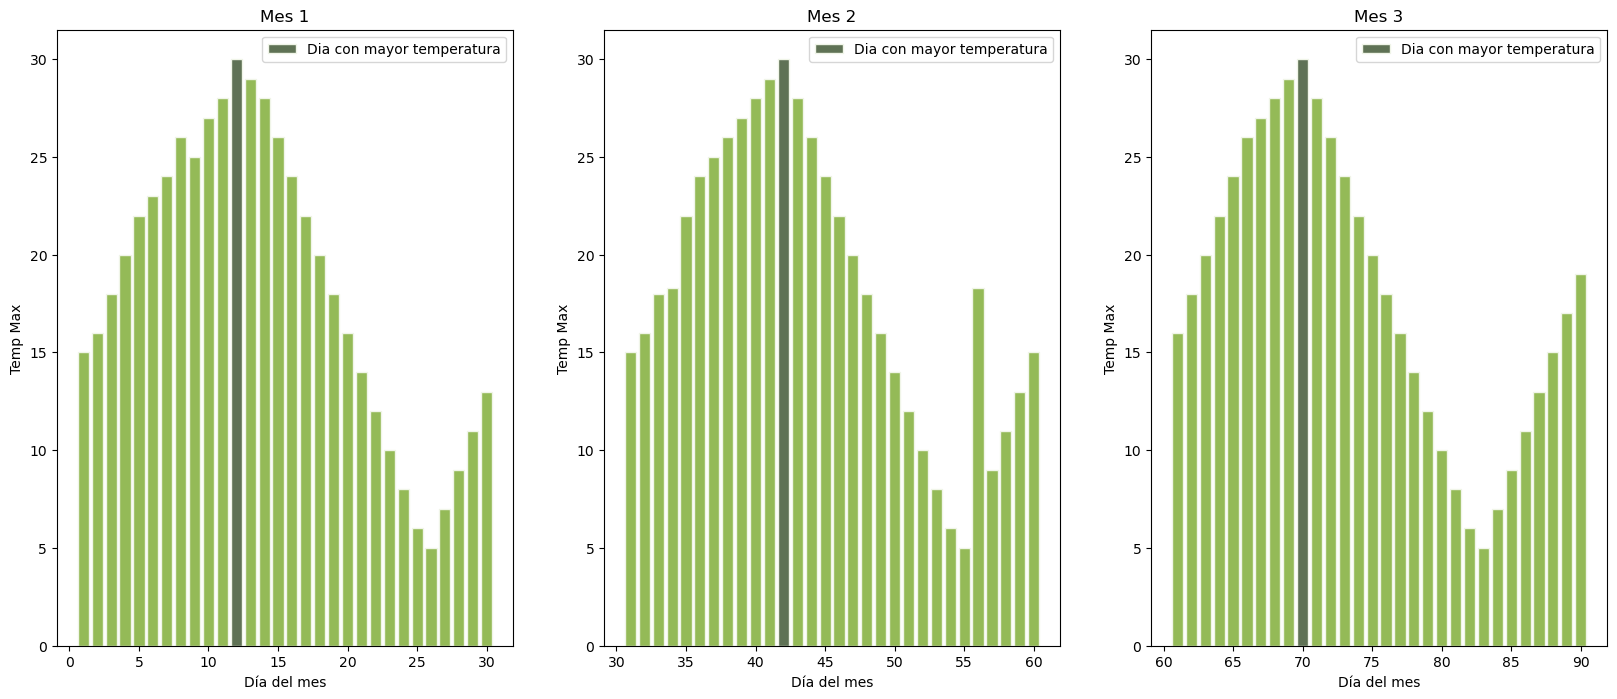

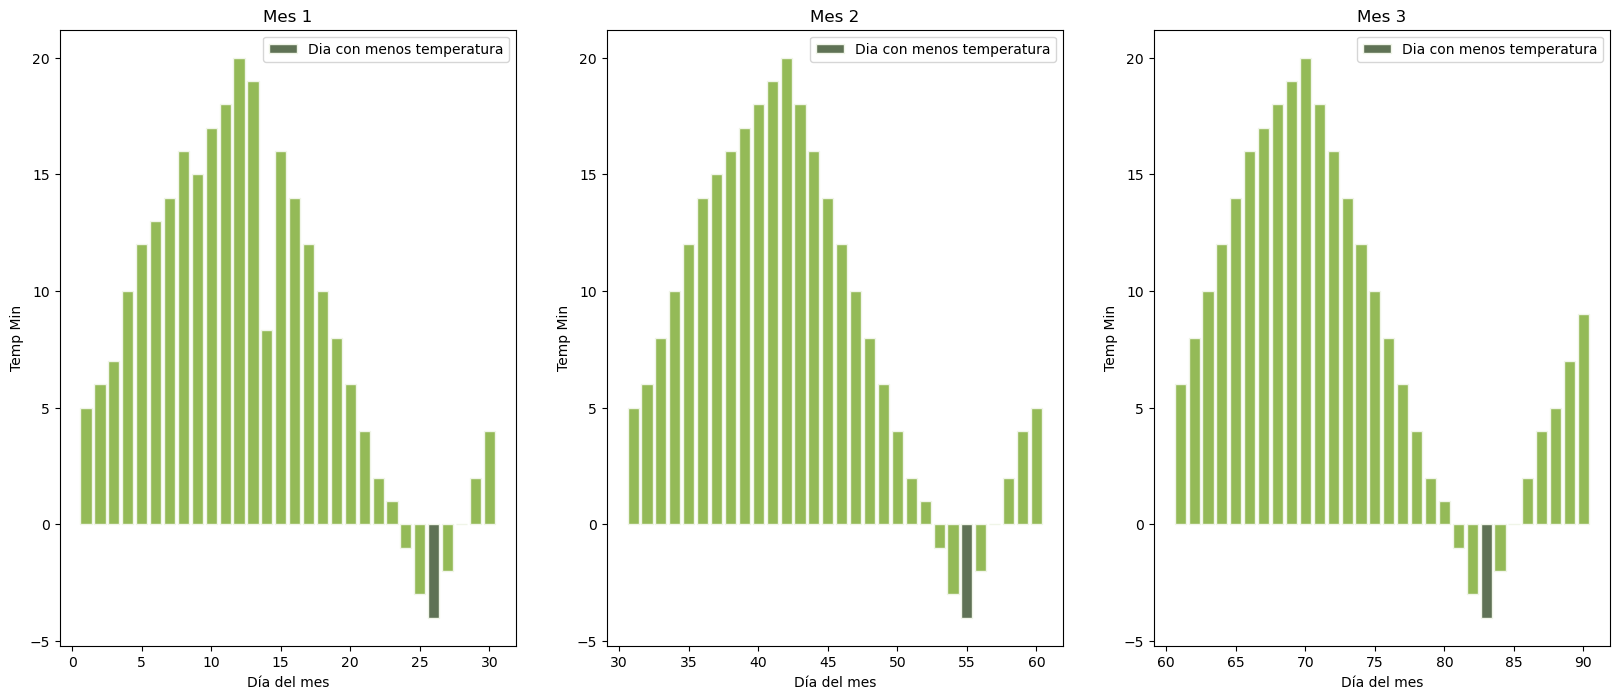

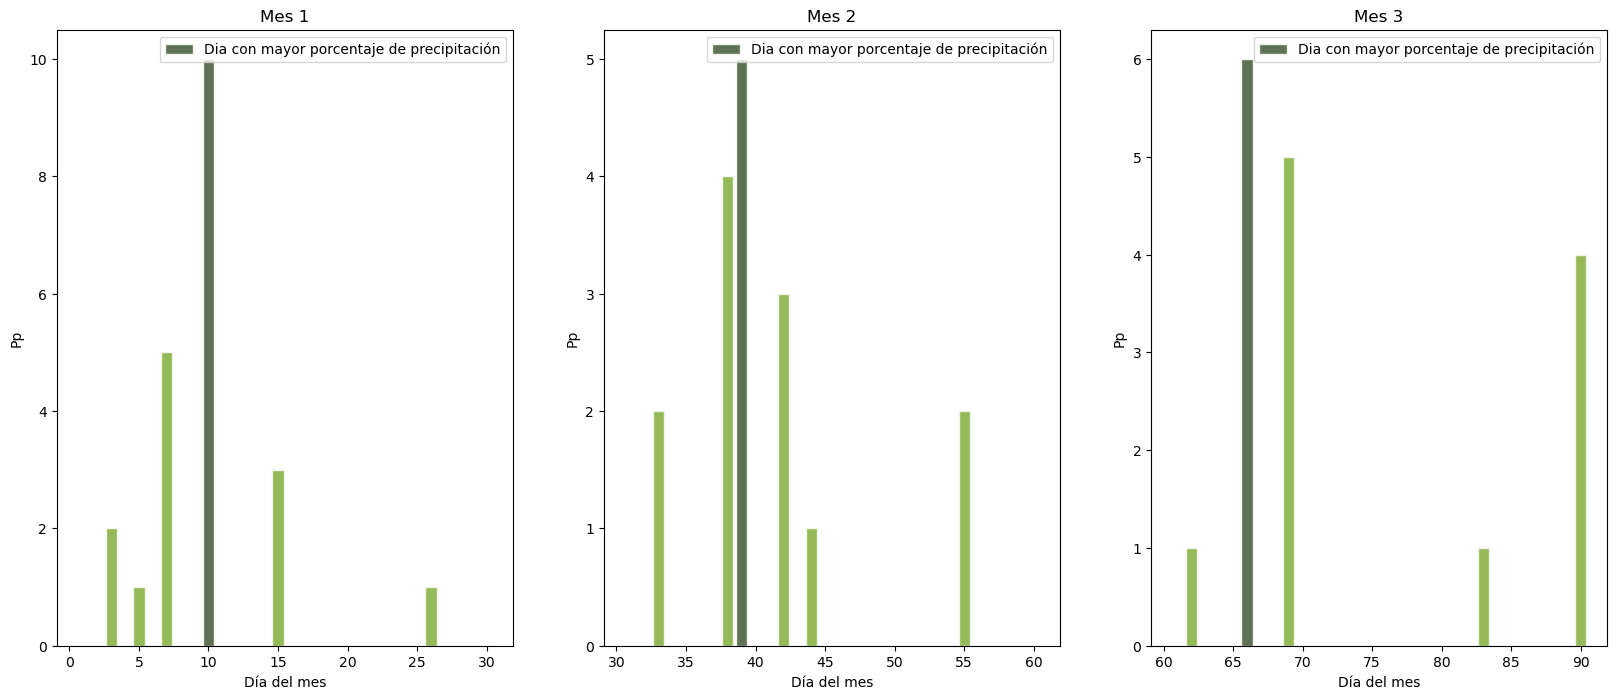

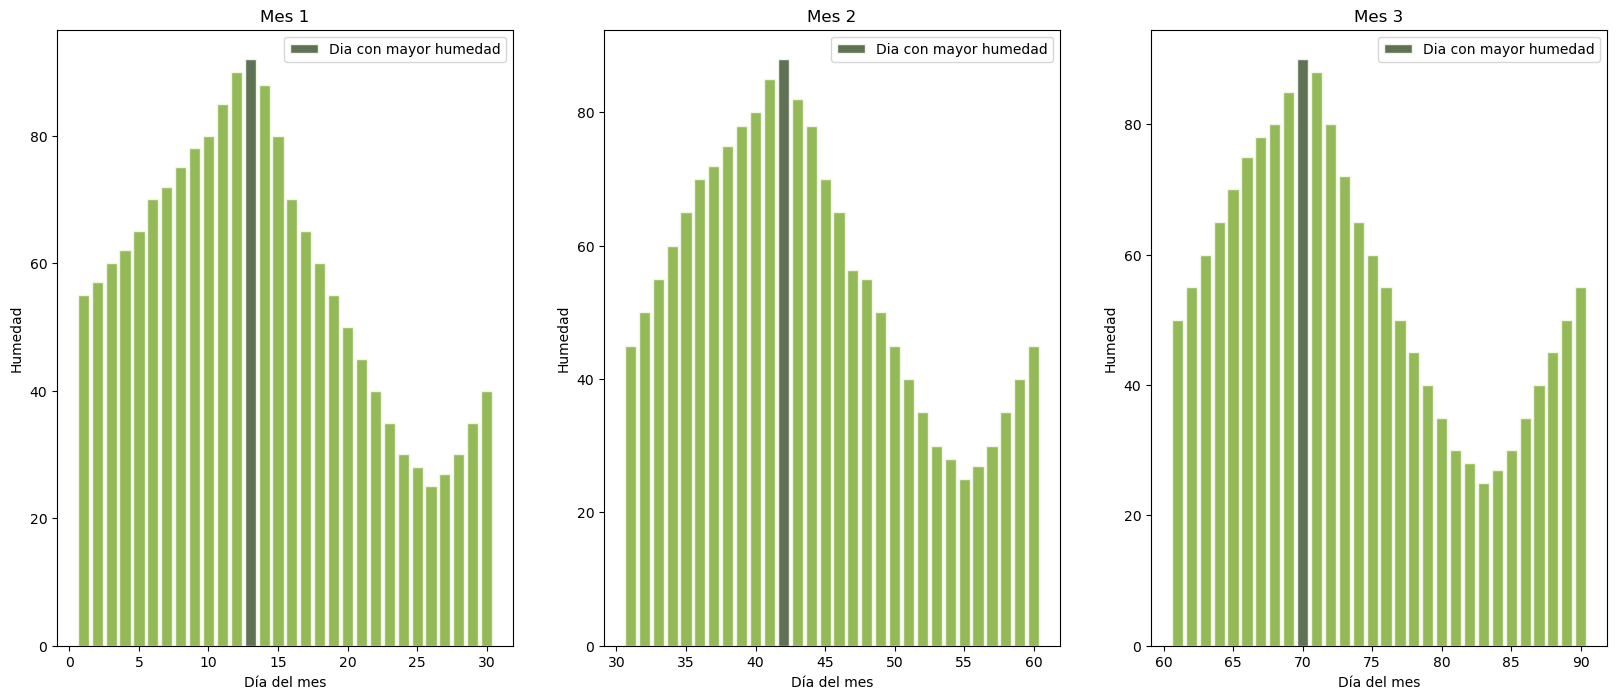

In [400]:
graf('Temp Max', np.max, 'mayor temperatura')
graf('Temp Min', np.min, 'menos temperatura')
graf('Pp', np.max, 'mayor porcentaje de precipitación')
graf('Humedad', np.max, 'mayor humedad')

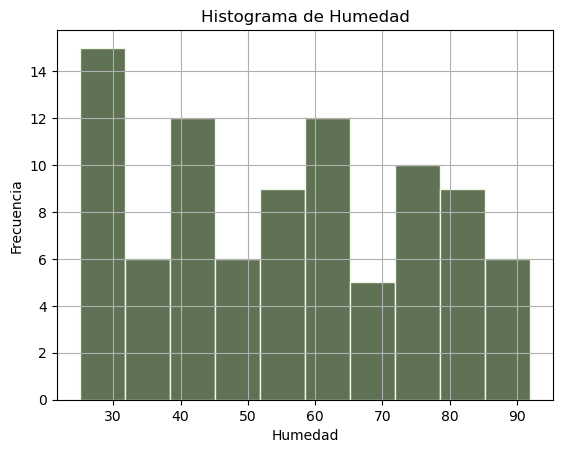

In [401]:
#Analicemos con un histograma la distribución de humedad en los  3 meses:
df["Humedad"].hist(bins=10, color='#5F7255', edgecolor="#f0f5e8")
plt.title('Histograma de Humedad')
plt.xlabel('Humedad')
plt.ylabel('Frecuencia')
plt.show()